In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("mail_data.csv")

In [3]:
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [7]:
df['Category'] = encoder.fit_transform(df['Category'])

In [8]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.isnull().sum() #checking missing values

Category    0
Message     0
dtype: int64

In [10]:
df.duplicated().sum() #checking duplicate values

np.int64(415)

In [11]:
df = df.drop_duplicates(keep = 'first')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(5157, 2)

### EDA

In [14]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df['Category'].value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x10e39c290>,
 [Text(-1.0171946362150524, 0.41870642705280725, 'ham'),
  Text(1.0171945729921292, -0.4187065806449194, 'spam')],
 [Text(-0.554833437935483, 0.22838532384698573, '87.57'),
  Text(0.5548334034502522, -0.22838540762450146, '12.43')])

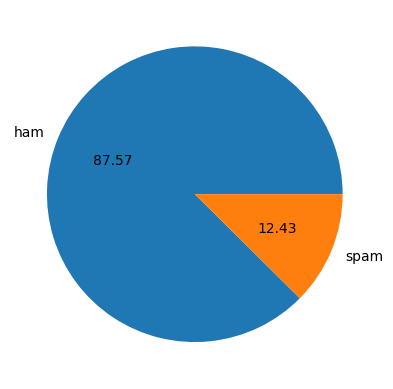

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts(), labels=['ham', 'spam'], autopct = "%0.2f")

In [17]:
#Data is imbalanced

In [18]:
# Number of characters in each message
df.loc[:, 'num_characters'] = df['Message'].apply(len)

# Number of words (simple split, no NLP library)
df.loc[:, 'num_words'] = df['Message'].apply(lambda x: len(x.split()))

# Number of sentences (basic punctuation-based approach)
df.loc[:, 'num_sentences'] = df['Message'].apply(
    lambda x: x.count('.') + x.count('!') + x.count('?')
)

In [19]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,15.410704,2.489044
std,58.382922,11.118902,2.721229
min,2.000000,1.000000,0.000000
25%,36.000000,7.000000,1.000000
50%,61.000000,12.000000,2.000000
75%,118.000000,22.000000,3.000000
max,910.000000,171.000000,42.000000


In [20]:
#For ham messages
df[df['Category'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,14.239814,2.416519
std,56.708301,11.179471,2.810813
min,2.000000,1.000000,0.000000
25%,34.000000,7.000000,1.000000
50%,53.000000,11.000000,2.000000
75%,91.000000,19.000000,3.000000
max,910.000000,171.000000,42.000000


In [21]:
#For spam messages
df[df['Category'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,14.239814,2.416519
std,56.708301,11.179471,2.810813
min,2.000000,1.000000,0.000000
25%,34.000000,7.000000,1.000000
50%,53.000000,11.000000,2.000000
75%,91.000000,19.000000,3.000000
max,910.000000,171.000000,42.000000


In [22]:
df.head()

,Category,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,8
1,0,Ok lar... Joking wif u oni...,29,6,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,6
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


### plotting it in a histogram graph

In [23]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

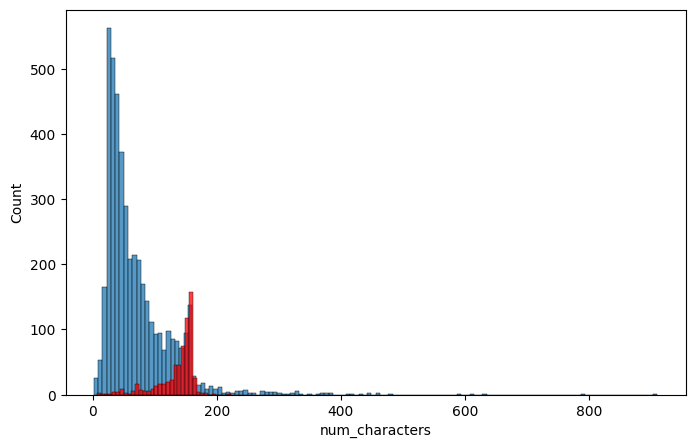

In [24]:
plt.figure(figsize = (8,5))
sns.histplot(df[df['Category'] == 0]['num_characters'])
sns.histplot(df[df['Category'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

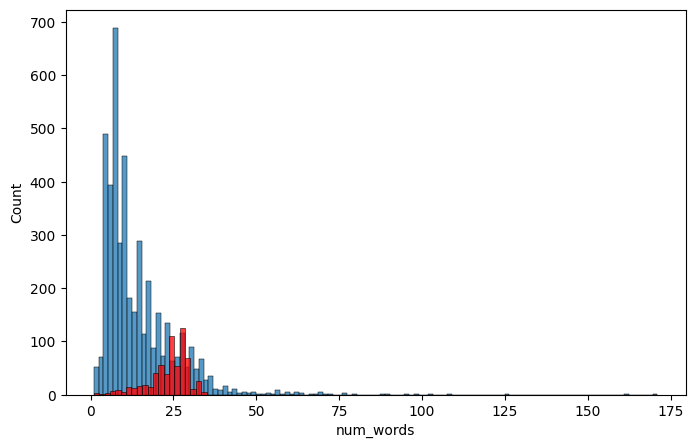

In [25]:
plt.figure(figsize = (8,5))
sns.histplot(df[df['Category'] == 0]['num_words'])
sns.histplot(df[df['Category'] == 1]['num_words'], color='red')

In [26]:
df.corr(numeric_only=True)

,Category,num_characters,num_words,num_sentences
Category,1.000000,0.374409,0.279540,0.070748
num_characters,0.374409,1.000000,0.973985,0.495756
num_words,0.279540,0.973985,1.000000,0.478690
num_sentences,0.070748,0.495756,0.478690,1.000000


### Data Preprocessing

In [27]:
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
import string

In [28]:
ps = PorterStemmer()
ps.stem('working')

'work'

In [29]:
def transform_text(Message):
    Message = Message.lower()
    Message = nltk.word_tokenize(Message)

    y = []
    for i in Message:
        if i.isalnum():
            y.append(i)

    Message = y[:]
    y.clear()

    for i in Message:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    Message = y[:]
    y.clear()

    for i in Message:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [30]:
transform_text('Hello, I am Subin Dulal.')

'hello subin dulal'

In [31]:
df['transformed_text'] = df['Message'].apply(transform_text)

In [32]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,8,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,6,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,6,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah think goe usf live around though


In [33]:
from wordcloud import WordCloud

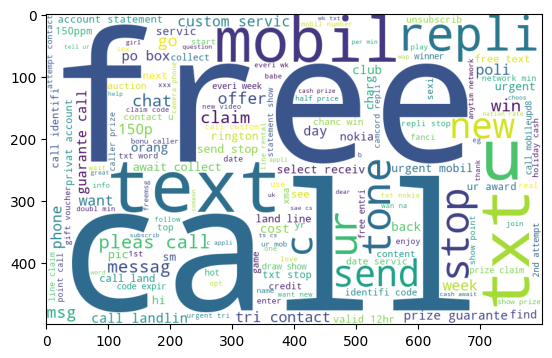

In [34]:
wc = WordCloud(width=800, height=500, min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['Category'] ==1] ['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

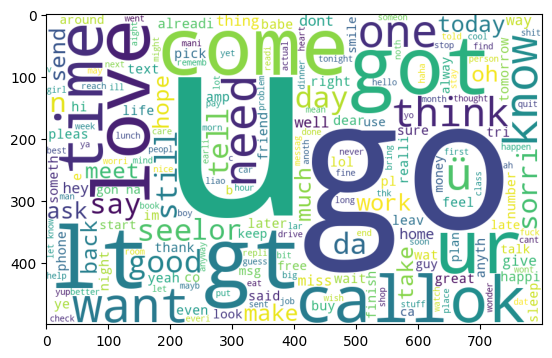

In [35]:
wc = WordCloud(width=800, height=500, min_font_size=10,background_color='white')
ham_wc = wc.generate(df[df['Category'] == 0] ['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [36]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,8,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,6,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,6,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah think goe usf live around though


### Text Vectorization using TF-IDF

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [39]:
X.shape

(5157, 3000)

In [40]:
y = df['Category'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5157,))

### Model Training

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Training Naive Bayes 

In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [44]:
mnb = MultinomialNB()

In [45]:
mnb.fit(X_train, y_train)
y_pred1 = mnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1 Score:", f1_score(y_test, y_pred1))

Accuracy: 0.9777131782945736
Confusion Matrix:
 [[896   0]
 [ 23 113]]
Precision: 1.0
Recall: 0.8308823529411765
F1 Score: 0.9076305220883534


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score 

In [47]:
lr = LogisticRegression()

In [48]:
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Performance
Accuracy: 0.9593023255813954
Precision: 0.97
Recall: 0.7132352941176471
F1 Score: 0.8220338983050848
Confusion Matrix:
 [[893   3]
 [ 39  97]]
